# Ejercicio 1 — KNN con el dataset diamonds

Vamos a predecir el precio de un diamante usando KNN.

Dataset: sns.load_dataset('diamonds') — 53,940 diamantes con sus características.

Tarea:

Cargar el dataset.
Codificar las 3 ordinales con OrdinalEncoder respetando el orden:
cut: Fair < Good < Very Good < Premium < Ideal
color: J < I < H < G < F < E < D (D es el mejor)
clarity: I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF
Definir y = price y X = el resto.
Train/test split 80/20, random_state=42.
OBLIGATORIO: estandarizar (KNN usa distancias).
Probar 3 valores de k: 5, 15, 30. ¿Cuál gana?
Reportar R², MAE y RMSE del mejor k.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
df = sns.load_dataset('diamonds')

print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

Primeras filas del DataFrame:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


Ultimas filas del DataFrame:
       carat        cut color clarity  depth  table  price     x     y     z
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64
Informacion del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  flo

In [3]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.800000     57.000000   2401.000000      5.700000   
75%        1.040000     62.500000     59.000000   5324.250000      6.540000   
max        5.010000     79.000000     95.000000  18823.000000     10.740000   

                  y             z  
count  53940.000000  53940.000000  
mean       5.734526      3.538734  
std        1.142135      0.705699  
min        0.000000      0.000000  
25%        4.720000      2.910000  
50%        5.710000      3.5300

In [4]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object


In [5]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 146


In [6]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


**Codificar variables ordinales**

In [7]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
df[['cut', 'color', 'clarity']] = encoder.fit_transform(df[['cut', 'color', 'clarity']])



**Definir X e y**

In [8]:
X = df.drop('price', axis=1)
y = df['price']

**Dividir dataset**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Escalamiento**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

**Probar distintos k**

In [11]:
k_values = [5, 15, 30]
results = {}

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    results[k] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

**Mostrar resultados**

In [12]:
results_df = pd.DataFrame(results).T

print('\nResultados:\n')
print(results_df)


Resultados:

          R2         MAE        RMSE
5   0.968054  374.333611  712.629415
15  0.967823  371.254802  715.202514
30  0.965966  382.456313  735.552918


**Mejor Modelo**

In [ ]:
best_k = results_df['R2'].idxmax()
print(f'\nMejor valor de k: {best_k}')
print('\nMetricas del mejor modelo:\n')
print(results_df.loc[best_k])


Mejor valor de k: 5

Metricas del mejor modelo:

R2        0.968054
MAE     374.333611
RMSE    712.629415
Name: 5, dtype: float64


**Regresion Lineal**

In [16]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

r2_linear = r2_score(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)

**Decision Tree Regressor**

In [17]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)

**Comparacion de resultados**

In [18]:
results = pd.DataFrame({'Modelo': ['Regresion Lineal', 'Decision Tree'], 'R2': [r2_linear, r2_tree], 'MAE': [mae_linear, mae_tree], 'RMSE': [rmse_linear, rmse_tree]})
print('\nResultados:\n')
print(results)


Resultados:

             Modelo        R2         MAE         RMSE
0  Regresion Lineal  0.905664  805.274366  1224.596542
1     Decision Tree  0.938831  568.874961   986.097800


**Visualizacion Arbol**

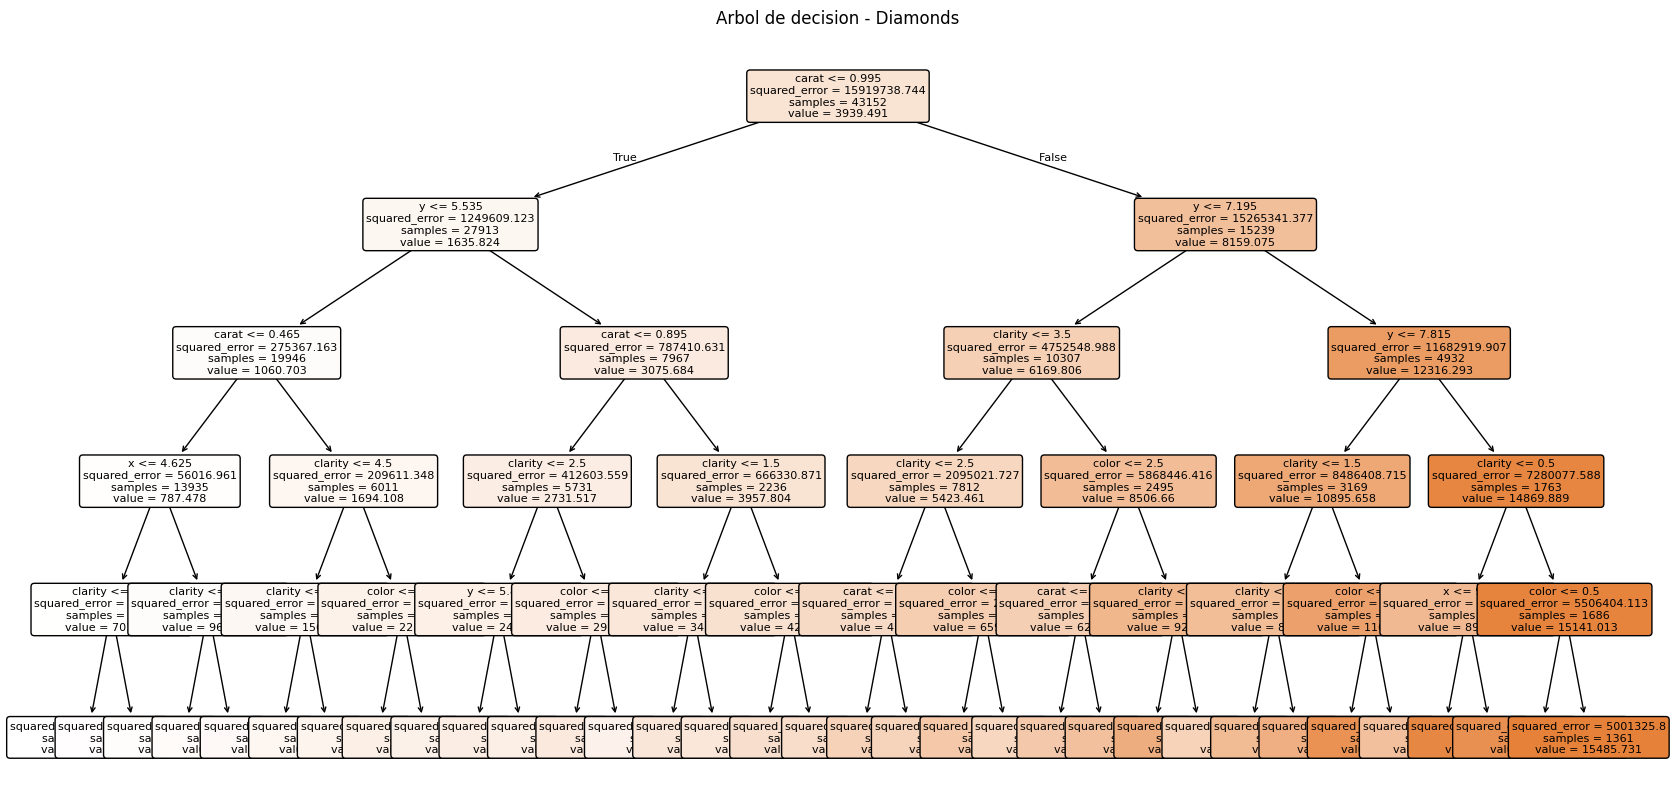

In [19]:
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.title('Arbol de decision - Diamonds')
plt.show()
